# Baseline Cointegration Anslysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import coint

In [3]:
df = pd.read_csv("../data/pep_ko_daily.csv", index_col=0)

## Regression on Raw Prices

To test that two time series $X_t$ and $Y_t$ are cointigrated, we must use the Engle Granger test (`statsmodels.tsa.stattools.coint`). The null and alternative hypotheses are as follows:
$$ H_0: \text{$X_t$ and $Y_t$ are not cointigrated}$$
$$ H_1: \text{$X_t$ and $Y_t$ are cointigrated}$$

By cointegration, we mean that when we regress $X_t$ on $Y_t$ using OLS, or vice versa, the residuals are stationary.

This test is infamously not symmetric, and a result may hold if $X_t$ is regressed on $Y_t$ but not the other way around. To mitigate for this, we will do the test both ways around to check for any 'disagreements'.

In [4]:
model_ko_pep = sm.OLS(df['close_pep'], sm.add_constant(df['close_ko']))
results_ko_pep = model_ko_pep.fit()

model_pep_ko = sm.OLS(df['close_ko'], sm.add_constant(df['close_pep']))
results_pep_ko = model_pep_ko.fit()

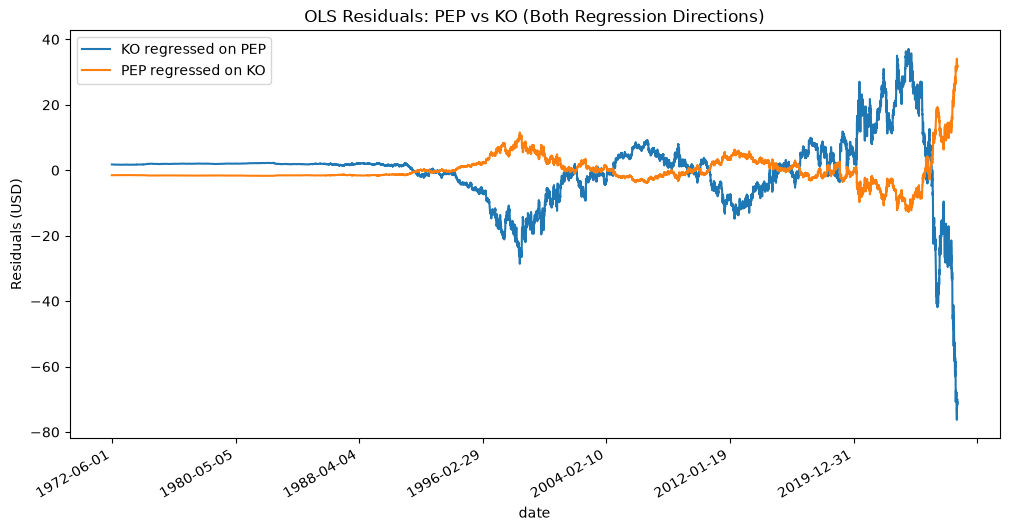

In [5]:
plt.figure(figsize=(12, 6))

results_ko_pep.resid.plot(label="KO regressed on PEP")
results_pep_ko.resid.plot(label="PEP regressed on KO")

plt.title("OLS Residuals: PEP vs KO (Both Regression Directions)")
plt.ylabel("Residuals (USD)")
plt.legend()

plt.gcf().autofmt_xdate()

plt.show()

In [6]:
_, pvalue_ko_pep, _ = coint(df['close_ko'], df['close_pep'])
_, pvalue_pep_ko, _ = coint(df['close_pep'], df['close_ko'])

In [7]:
print("KO regressed on PEP - Cointegration identified: ", pvalue_ko_pep<=0.05, "\np-value: ", pvalue_ko_pep, "\n")
print("PEP regressed on KO - Cointegration identified: ", pvalue_pep_ko<=0.05, "\np-value: ", pvalue_pep_ko)

KO regressed on PEP - Cointegration identified:  False 
p-value:  0.9857284606424307 

PEP regressed on KO - Cointegration identified:  False 
p-value:  0.9510748741240085


## Regression on Log Prices

Prices scale by orders of magnitude over time and, as such, price differences in early decades of our dataset are tiny compared to that of later decades. This is reflected in the above plots where the residuals are very small at first but the variances gradually grow over time. 

Taking the log of both prices and regressing these quantities on one another means the residual represents the log of a price ratio, rather than a raw price difference. Since ratios are scale-invariant, this residual is more likely to remain stable in magnitude regardless of the absolute price level — unlike a raw-price residual, whose scale mechanically grows alongside the stocks' price appreciation.

In [11]:
df_log = df[[]].copy()
df_log['log_close_pep'] = np.log(df['close_pep'])
df_log['log_close_ko'] = np.log(df['close_ko'])

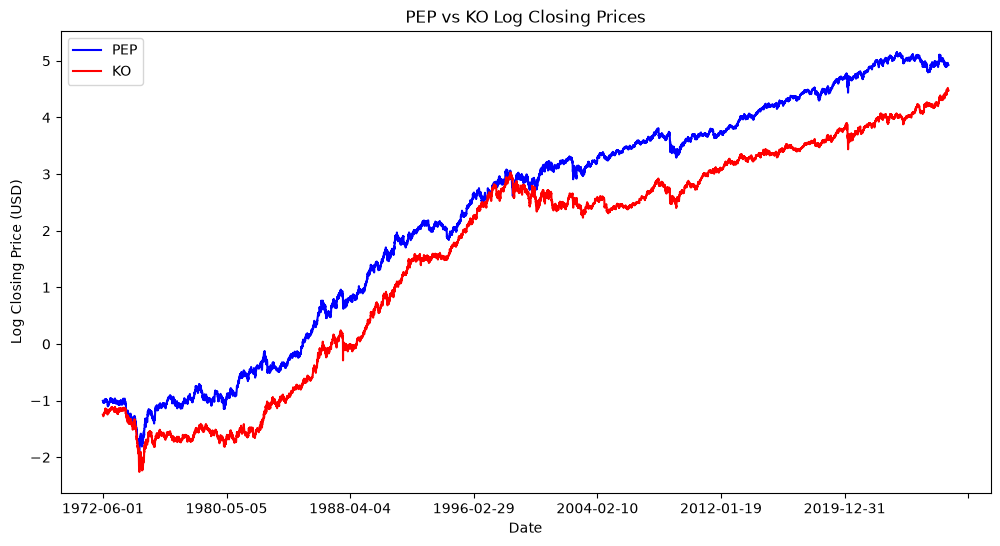

In [13]:
plt.figure(figsize=(12, 6))

df_log["log_close_pep"].plot(label="PEP", color="blue")
df_log["log_close_ko"].plot(label="KO", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Log Closing Price (USD)")
plt.title("PEP vs KO Log Closing Prices")

plt.show()

In [14]:
model_log_ko_pep = sm.OLS(df_log['log_close_pep'], sm.add_constant(df_log['log_close_ko']))
results_log_ko_pep = model_log_ko_pep.fit()

model_log_pep_ko = sm.OLS(df_log['log_close_ko'], sm.add_constant(df_log['log_close_pep']))
results_log_pep_ko = model_log_pep_ko.fit()

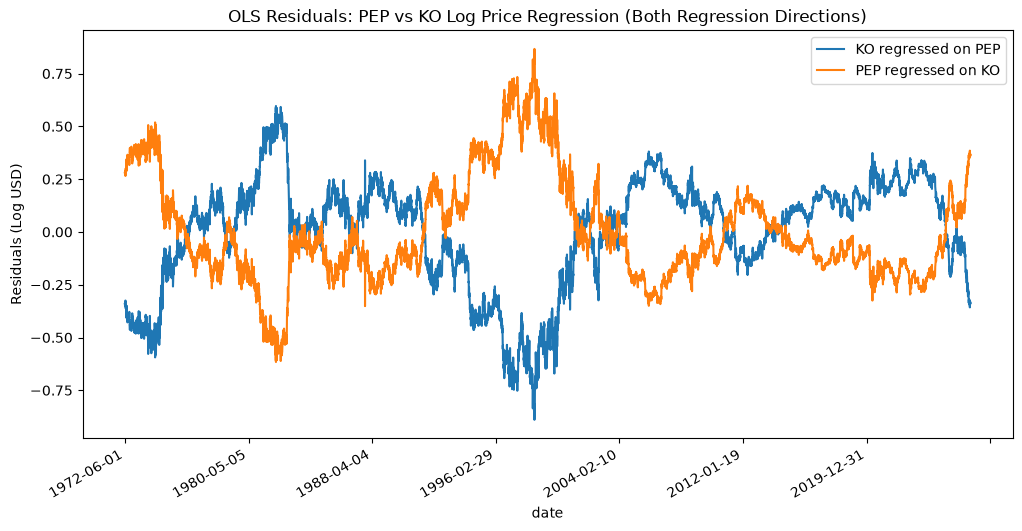

In [15]:
plt.figure(figsize=(12, 6))

results_log_ko_pep.resid.plot(label="KO regressed on PEP")
results_log_pep_ko.resid.plot(label="PEP regressed on KO")

plt.title("OLS Residuals: PEP vs KO Log Price Regression (Both Regression Directions)")
plt.ylabel("Residuals (Log USD)")
plt.legend()

plt.gcf().autofmt_xdate()

plt.show()

In [16]:
_, pvalue_log_ko_pep, _ = coint(df_log['log_close_ko'], df_log['log_close_pep'])
_, pvalue_log_pep_ko, _ = coint(df_log['log_close_pep'], df_log['log_close_ko'])

In [17]:
print("KO regressed on PEP (Log Price) - Cointegration identified: ", pvalue_log_ko_pep<=0.05, "\np-value: ", pvalue_log_ko_pep, "\n")
print("PEP regressed on KO (Log Price) - Cointegration identified: ", pvalue_log_pep_ko<=0.05, "\np-value: ", pvalue_log_pep_ko)

KO regressed on PEP (Log Price) - Cointegration identified:  False 
p-value:  0.3566026357632628 

PEP regressed on KO (Log Price) - Cointegration identified:  False 
p-value:  0.31100223356297707
